In [64]:
%pip install pandas numpy spacy matplotlib plotly scikit-learn beautifulsoup4 nltk bertopic optuna optuna-dashboard

Note: you may need to restart the kernel to use updated packages.


In [65]:
import random
import time

import hdbscan
import numpy as np
import optuna
import pandas as pd
import umap
from bertopic import BERTopic
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

## BERTopic

In [66]:
# Carga de datos
test = pd.read_csv("data/research-articles/test.csv")
train = pd.read_csv("data/research-articles/train.csv")

display(test.head())
display(train.head())

,ID,TITLE,ABSTRACT
0,20973,Closed-form Marginal Likelihood in Gamma-Poiss...,We present novel understandings of the Gamma...
1,20974,Laboratory mid-IR spectra of equilibrated and ...,Meteorites contain minerals from Solar Syste...
2,20975,Case For Static AMSDU Aggregation in WLANs,Frame aggregation is a mechanism by which mu...
3,20976,The $Gaia$-ESO Survey: the inner disk intermed...,Milky Way open clusters are very diverse in ...
4,20977,Witness-Functions versus Interpretation-Functi...,Proving that a cryptographic protocol is cor...


,ID,TITLE,ABSTRACT,Computer Science,Physics,Mathematics,Statistics,Quantitative Biology,Quantitative Finance
0,1,Reconstructing Subject-Specific Effect Maps,Predictive models allow subject-specific inf...,1,0,0,0,0,0
1,2,Rotation Invariance Neural Network,Rotation invariance and translation invarian...,1,0,0,0,0,0
2,3,Spherical polyharmonics and Poisson kernels fo...,We introduce and develop the notion of spher...,0,0,1,0,0,0
3,4,A finite element approximation for the stochas...,The stochastic Landau--Lifshitz--Gilbert (LL...,0,0,1,0,0,0
4,5,Comparative study of Discrete Wavelet Transfor...,Fourier-transform infra-red (FTIR) spectra o...,1,0,0,1,0,0


In [67]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20972 entries, 0 to 20971
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    20972 non-null  int64 
 1   TITLE                 20972 non-null  object
 2   ABSTRACT              20972 non-null  object
 3   Computer Science      20972 non-null  int64 
 4   Physics               20972 non-null  int64 
 5   Mathematics           20972 non-null  int64 
 6   Statistics            20972 non-null  int64 
 7   Quantitative Biology  20972 non-null  int64 
 8   Quantitative Finance  20972 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 1.4+ MB


In [68]:
train.dtypes

ID                       int64
TITLE                   object
ABSTRACT                object
Computer Science         int64
Physics                  int64
Mathematics              int64
Statistics               int64
Quantitative Biology     int64
Quantitative Finance     int64
dtype: object

In [69]:
# trabajamos con menos documentos, para facilitar la ejecución y bajar tiempos de procesamiento
train_small = train.sample(n=500, random_state=42)
documents = list(train_small.ABSTRACT.values) # utilizaremos solo la columan Abstract como los documentos

In [70]:
clean_text = documents
tokenized_texts = [doc.split() for doc in clean_text]
dictionary = Dictionary(tokenized_texts)
dictionary.filter_extremes(no_below=5, no_above=0.8)

In [71]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
EMBEDDING_MODEL = "all-MiniLM-L6-v2"   # puedes cambiar por otro si deseas
embedder = SentenceTransformer(EMBEDDING_MODEL)

print("Calculando embeddings (esto puede tardar)...")
t0 = time.time()
embeddings = embedder.encode(clean_text, show_progress_bar=True, convert_to_numpy=True)
print(f"Embeddings calculados en {time.time()-t0:.1f}s. shape = {embeddings.shape}")

Calculando embeddings (esto puede tardar)...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Embeddings calculados en 8.6s. shape = (500, 384)


In [72]:
def extract_topic_words_from_bertopic(model, top_n=12):
    topic_dict = model.get_topics()  # dict {topic_id: [(word, score), ...], ...}
    # excluir tópico -1 (outliers)
    topic_ids = sorted([tid for tid in topic_dict.keys() if tid != -1])
    topics_words = []
    for tid in topic_ids:
        words_weights = topic_dict[tid][:top_n]
        words = [w for w, _ in words_weights]
        topics_words.append(words)
    return topic_ids, topics_words

In [73]:

def objective(trial):
    # ===== hiperparámetros =====
    # UMAP
    n_neighbors = trial.suggest_int("umap_n_neighbors", 5, 50)
    n_components = trial.suggest_int("umap_n_components", 2, 15)
    min_dist = trial.suggest_float("umap_min_dist", 0.0, 0.99)
    metric = trial.suggest_categorical("umap_metric", ["cosine", "euclidean"])

    # HDBSCAN
    min_cluster_size = trial.suggest_int("hdbscan_min_cluster_size", 5, 50)
    min_samples = trial.suggest_int("hdbscan_min_samples", 1, 20)

    # Vectorizer
    min_df = trial.suggest_int("vect_min_df", 1, 5)
    ngram = trial.suggest_categorical("vect_ngram", [(1,1), (1,2)])

    # Otros
    top_n = trial.suggest_int("top_n", 8, 20)  # top words por topic para coherencia

    # ===== Construir sub-componentes con esos hiperparámetros =====
    umap_model = umap.UMAP(n_neighbors=n_neighbors,
                          n_components=n_components,
                          min_dist=min_dist,
                          metric=metric,
                          random_state=RANDOM_SEED)

    # HDBSCAN: use 'euclidean' usualmente sobre embeddings reducidos por UMAP
    hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                    min_samples=min_samples,
                                    metric='euclidean',
                                    cluster_selection_method='eom',
                                    prediction_data=True)

    vectorizer_model = CountVectorizer(stop_words='english', min_df=min_df, ngram_range=ngram)

    # ===== Crear y ajustar BERTopic (solo sobre embeddings ya calculados) =====
    try:
        model = BERTopic(embedding_model=embedder,
                         umap_model=umap_model,
                         hdbscan_model=hdbscan_model,
                         vectorizer_model=vectorizer_model,
                         calculate_probabilities=False,  # no necesitamos probabilidades para evaluación
                         verbose=False,
                         language="english")
        t0 = time.time()
        topics, probs = model.fit_transform(clean_text, embeddings)  # usa embeddings precomputados
        elapsed = time.time() - t0
    except Exception as e:
        # Si falla el ajuste, penalizar
        trial.set_user_attr("error", str(e))
        return -1e6

    # ===== Extraer topics y calcular coherencia c_v =====
    topic_ids, topic_words = extract_topic_words_from_bertopic(model, top_n=top_n)

    # Si no se han obtenido topics (p. ej. todos outliers), penalizar
    if len(topic_words) == 0:
        trial.set_user_attr("n_topics", 0)
        return -1e6

    # Calcular coherencia c_v con gensim
    try:
        cm = CoherenceModel(topics=topic_words, texts=tokenized_texts, dictionary=dictionary, coherence='c_v')
        coherence = cm.get_coherence()
    except Exception as e:
        trial.set_user_attr("coherence_error", str(e))
        return -1e6

    # Registrar algunos atributos útiles del trial
    trial.set_user_attr("elapsed_s", elapsed)
    trial.set_user_attr("n_topics", len(topic_words))
    trial.set_user_attr("vocab_size", len(model.get_topic_info()))
    # Optuna maximiza
    return float(coherence)

In [74]:
def run_optuna_bertopic(n_trials=30, study_name="bertopic_optuna", storage=None, save_study_path="bertopic_optuna_study.pkl"):
    """
    Ejecuta Optuna para optimizar hiperparámetros de BERTopic.
    - n_trials: nº de trials a ejecutar.
    - storage: string para RDB storage si quieres paralelizar/distribuir (opcional).
    - save_study_path: ruta para guardar el estudio con joblib.
    Devuelve: study, best_model (re-entrenado sobre todo el corpus), df_trials (pandas).
    """
    sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
    study = optuna.create_study(study_name=study_name, direction="maximize", sampler=sampler, storage=storage, load_if_exists=True)
    print("Iniciando optimización Optuna para BERTopic. n_trials =", n_trials)
    study.optimize(objective, n_trials=n_trials)

    print("Mejor coherencia encontrada:", study.best_value)
    print("Mejores hiperparámetros:", study.best_params)

    # ===== Reentrenar mejor modelo sobre todo el corpus =====
    best = study.best_params
    # reconstruir componentes con los mejores hiperparámetros
    best_umap = umap.UMAP(n_neighbors=best["umap_n_neighbors"],
                          n_components=best["umap_n_components"],
                          min_dist=best["umap_min_dist"],
                          metric=best["umap_metric"],
                          random_state=RANDOM_SEED)

    best_hdbscan = hdbscan.HDBSCAN(min_cluster_size=best["hdbscan_min_cluster_size"],
                                   min_samples=best["hdbscan_min_samples"],
                                   metric='euclidean',
                                   cluster_selection_method='eom',
                                   prediction_data=True)

    best_vectorizer = CountVectorizer(stop_words='english',
                                      min_df=best["vect_min_df"],
                                      ngram_range=best["vect_ngram"])

    best_model = BERTopic(embedding_model=embedder,
                          umap_model=best_umap,
                          hdbscan_model=best_hdbscan,
                          vectorizer_model=best_vectorizer,
                          calculate_probabilities=True,  # útil para análisis posterior
                          verbose=True,
                          language="english")

    print("Reentrenando el mejor BERTopic sobre todo el corpus...")
    t0 = time.time()
    topics, probs = best_model.fit_transform(clean_text, embeddings)
    print(f"Reentrenado en {time.time()-t0:.1f}s. Número de topics (excluyendo -1):",
          len([tid for tid in best_model.get_topic_info().Topic if tid != -1]) if hasattr(best_model.get_topic_info(), "Topic") else "N/A")

    # ===== Crear DataFrame de resultados de trials =====
    trials_df = study.trials_dataframe()
    return study, best_model, trials_df

In [75]:
# Ajusta n_trials según tu tiempo; 20-40 para exploración inicial
study, best_bertopic_model, trials_df = run_optuna_bertopic(n_trials=30, save_study_path="bertopic_optuna_study.pkl")

# Mostrar top palabras del mejor modelo en un DataFrame (igual que con LDA)
best_topic_ids, best_topic_words = extract_topic_words_from_bertopic(best_bertopic_model, top_n=12)
df_topics_best = pd.DataFrame({
    "topic_id": best_topic_ids,
    "top_words": [", ".join(words) for words in best_topic_words]
})
display(df_topics_best)

[I 2025-11-30 22:30:04,963] A new study created in memory with name: bertopic_optuna


Iniciando optimización Optuna para BERTopic. n_trials = 30


[I 2025-11-30 22:30:07,770] Trial 0 finished with value: 0.4288047321920178 and parameters: {'umap_n_neighbors': 22, 'umap_n_components': 15, 'umap_min_dist': 0.724674002393291, 'umap_metric': 'cosine', 'hdbscan_min_cluster_size': 12, 'hdbscan_min_samples': 2, 'vect_min_df': 5, 'vect_ngram': (1, 2), 'top_n': 8}. Best is trial 0 with value: 0.4288047321920178.
[I 2025-11-30 22:30:10,569] Trial 1 finished with value: 0.46578147853571356 and parameters: {'umap_n_neighbors': 49, 'umap_n_components': 13, 'umap_min_dist': 0.2102157195714934, 'umap_metric': 'euclidean', 'hdbscan_min_cluster_size': 18, 'hdbscan_min_samples': 11, 'vect_min_df': 3, 'vect_ngram': (1, 2), 'top_n': 9}. Best is trial 1 with value: 0.46578147853571356.
[I 2025-11-30 22:30:13,049] Trial 2 finished with value: 0.5558132461713338 and parameters: {'umap_n_neighbors': 18, 'umap_n_components': 7, 'umap_min_dist': 0.45150928437486554, 'umap_metric': 'cosine', 'hdbscan_min_cluster_size': 28, 'hdbscan_min_samples': 12, 'vect_

Mejor coherencia encontrada: 0.5558132461713338
Mejores hiperparámetros: {'umap_n_neighbors': 18, 'umap_n_components': 7, 'umap_min_dist': 0.45150928437486554, 'umap_metric': 'cosine', 'hdbscan_min_cluster_size': 28, 'hdbscan_min_samples': 12, 'vect_min_df': 1, 'vect_ngram': (1, 1), 'top_n': 8}
Reentrenando el mejor BERTopic sobre todo el corpus...


2025-11-30 22:31:23,860 - BERTopic - Dimensionality - Completed ✓
2025-11-30 22:31:23,861 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-30 22:31:23,878 - BERTopic - Cluster - Completed ✓
2025-11-30 22:31:23,880 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-30 22:31:23,923 - BERTopic - Representation - Completed ✓


Reentrenado en 0.7s. Número de topics (excluyendo -1): 4


,topic_id,top_words
0,0,"data, based, learning, network, method, networ..."
1,1,"mathbb, theory, finite, prove, algebras, tau, ..."
2,2,"magnetic, spin, field, phase, state, temperatu..."
3,3,"mass, star, galaxies, formation, galaxy, dark,..."


In [76]:
best_bertopic_model.visualize_topics()

In [77]:
best_bertopic_model.visualize_hierarchy()

In [78]:
best_bertopic_model.visualize_barchart()

In [79]:
best_bertopic_model.visualize_heatmap(top_n_topics=20)

Topic 0


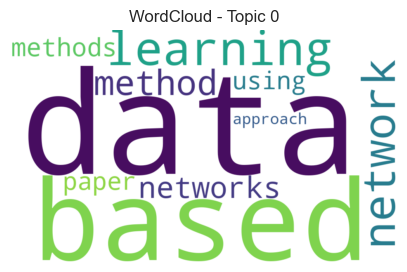

Topic 1


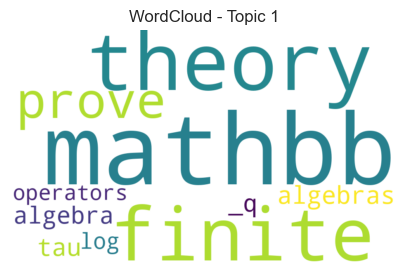

Topic 2


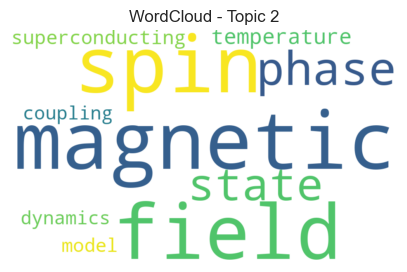

Topic 3


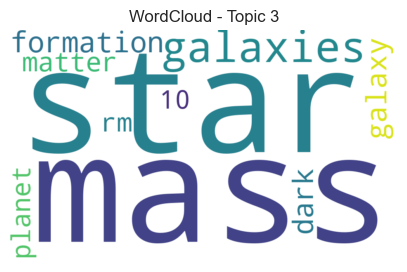

In [80]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_wordcloud(model, topic, max_words=50):
    topic_data = model.get_topics()[topic]
    words = {word: score for word, score in topic_data}

    wc = WordCloud(
        background_color="white",
        width=1000,
        height=600,
        max_words=max_words
    ).generate_from_frequencies(words)

    plt.figure(figsize=(5, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud - Topic {topic}")
    plt.show()


topics = best_bertopic_model.get_topics()

for topic_id in range(4):
    if topic_id == -1:
        continue   # omitir outliers

    print(f"Topic {topic_id}")
    plot_wordcloud(best_bertopic_model, topic=topic_id)